In [2]:
# Install libraries (only needed once in notebook)
# gensim = for word vectors, numpy = math
!pip install gensim numpy

# Import required modules
import gensim.downloader as api
import numpy as np

# Load pre-trained word vectors (big dataset of word meanings)
print("Loading model...")
word_vectors = api.load("word2vec-google-news-300")

# ---------------------------------------------------
# 1. WORD RELATIONSHIP (king - man + woman = queen)
# ---------------------------------------------------
def explore_word_relationships(w1, w2, w3):
    try:
        # Get vector (numeric meaning) of each word
        v1 = word_vectors[w1]
        v2 = word_vectors[w2]
        v3 = word_vectors[w3]

        # Do vector math
        result = v1 - v2 + v3

        # Find similar words to result
        words = word_vectors.similar_by_vector(result, topn=5)

        print(f"\n{w1} - {w2} + {w3} = ")
        for word, score in words:
            print(word, score)

    except:
        print("Word not found")

# Examples
explore_word_relationships("king", "man", "woman")
explore_word_relationships("paris", "france", "germany")

# ---------------------------------------------------
# 2. SIMILARITY BETWEEN TWO WORDS
# ---------------------------------------------------
def analyze_similarity(w1, w2):
    try:
        # Gives value between 0 and 1 (closer to 1 = more similar)
        sim = word_vectors.similarity(w1, w2)
        print(f"{w1} vs {w2} = {sim:.4f}")
    except:
        print("Word not found")

# Examples
analyze_similarity("cat", "dog")
analyze_similarity("music", "art")

# ---------------------------------------------------
# 3. FIND SIMILAR WORDS
# ---------------------------------------------------
def find_most_similar(word):
    try:
        # Get top 5 similar words
        words = word_vectors.most_similar(word, topn=5)

        print(f"\nSimilar words to {word}:")
        for w, score in words:
            print(w, score)

    except:
        print("Word not found")

# Examples
find_most_similar("happy")
find_most_similar("technology")

Loading model...

king - man + woman = 
king 0.8449392318725586
queen 0.7300517559051514
monarch 0.645466148853302
princess 0.6156251430511475
crown_prince 0.5818676352500916

paris - france + germany = 
paris 0.7316325902938843
germany 0.6952009797096252
berlin 0.48383620381355286
german 0.4694601595401764
lindsay_lohan 0.4535733461380005
cat vs dog = 0.7609
music vs art = 0.4010

Similar words to happy:
glad 0.7408890724182129
pleased 0.6632170677185059
ecstatic 0.6626912355422974
overjoyed 0.6599286794662476
thrilled 0.6514049172401428

Similar words to technology:
technologies 0.8332264423370361
innovations 0.6230790615081787
technological_innovations 0.6102177500724792
technol 0.6047338247299194
technological_advancement 0.6036396622657776


Loading model...


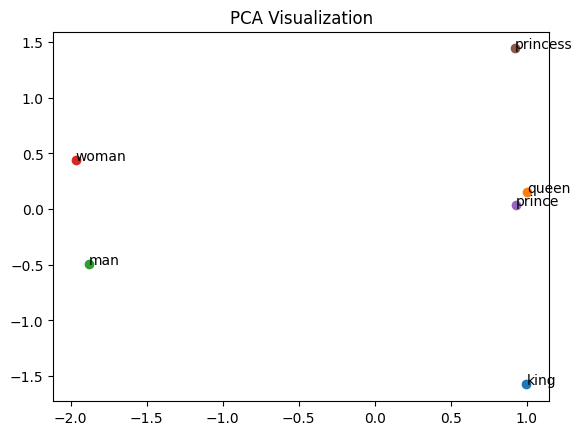

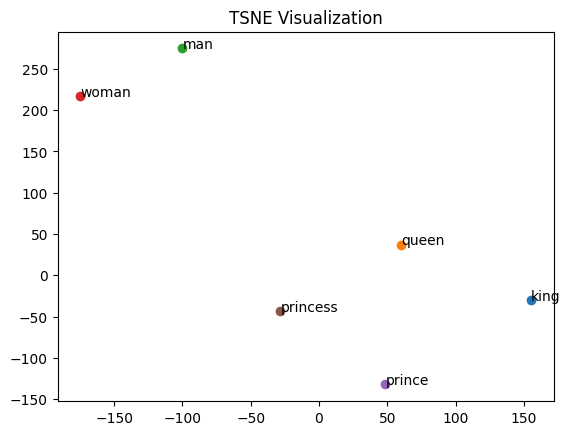

In [5]:
# ===================================================
# INSTALL (run once)
# ===================================================
!pip install gensim numpy matplotlib scikit-learn

# ===================================================
# IMPORTS
# ===================================================
import gensim.downloader as api
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# ===================================================
# LOAD MODEL
# ===================================================
print("Loading model...")
word_vectors = api.load("word2vec-google-news-300")

# ===================================================
# VISUALIZATION FUNCTION
# ===================================================
def visualize(words, vectors, method='pca'):

    if method == 'pca':
        reducer = PCA(n_components=2)
    elif method == 'tsne':
        reducer = TSNE(n_components=2, random_state=42, perplexity=3)
    else:
        print("Invalid method")
        return

    reduced = reducer.fit_transform(vectors)

    plt.figure()

    for i, word in enumerate(words):
        plt.scatter(reduced[i, 0], reduced[i, 1])
        plt.text(reduced[i, 0], reduced[i, 1], word)

    plt.title(f"{method.upper()} Visualization")
    plt.show()

# ===================================================
# MAIN
# ===================================================
words = ["king", "queen", "man", "woman", "prince", "princess"]

vectors = np.array([word_vectors[w] for w in words])

# PCA
visualize(words, vectors, method='pca')

# t-SNE
visualize(words, vectors, method='tsne')

In [6]:
# ===================================================
# INSTALL (run once)
# ===================================================
!pip install gensim transformers torch

# ===================================================
# IMPORTS
# ===================================================
import gensim.downloader as api
from transformers import pipeline
import string

# ===================================================
# LOAD WORD VECTORS
# ===================================================
print("Loading GloVe model...")
word_vectors = api.load("glove-wiki-gigaword-100")

# ===================================================
# PROMPT IMPROVEMENT FUNCTION
# ===================================================
def improve_prompt(prompt, keyword):
    words = prompt.split()
    new_words = []

    for w in words:
        clean = w.lower().strip(string.punctuation)

        if clean == keyword:
            try:
                sim = word_vectors.most_similar(clean, topn=1)
                replacement = sim[0][0]
                print(f"{w} -> {replacement}")
                new_words.append(replacement)
                continue
            except KeyError:
                pass

        new_words.append(w)

    new_prompt = " ".join(new_words)
    print("Improved Prompt:", new_prompt)
    return new_prompt

# ===================================================
# LOAD GPT MODEL
# ===================================================
print("Loading GPT-2...")
generator = pipeline("text-generation", model="gpt2")

# ===================================================
# GENERATE FUNCTION
# ===================================================
def generate(prompt):
    result = generator(prompt, max_length=50, num_return_sequences=1)
    return result[0]['generated_text']

# ===================================================
# MAIN
# ===================================================
prompt = "Who is king"
print("Original Prompt:", prompt)

new_prompt = improve_prompt(prompt, "king")

print("\nOriginal Output:")
print(generate(prompt))

print("\nImproved Output:")
print(generate(new_prompt))

Loading GloVe model...
[==================================================] 100.0% 128.1/128.1MB downloaded
Loading GPT-2...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

...

Original Prompt: Who is king


Passing `generation_config` together with generation-related arguments=({'max_length', 'num_return_sequences'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


king -> prince
Improved Prompt: Who is prince

Original Output:


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Who is king of this world? Who is ruler of this world? And who is an inhabitant of this world?

He's not the only one who's king. He's the one who has the power to make an end of the world. If we take control of all the world, then we can make all the world a paradise. If we go for the very thing that gives us the power to make the world a paradise, then we can make it a paradise at will. This is what we have to do.

If we're able to make this world a paradise, then we can make it a paradise right from the beginning. If we want to make it a paradise, we have to make it a paradise. Otherwise, we're not going to make it a paradise. This is why we have to make it a paradise right from the beginning.

Now, if we've got this power, we can make it a paradise. We've got to make it a paradise. And we've got to make it a paradise right from the beginning. Otherwise, we're not going to make it a paradise. This is why we have to make it a paradise.

How can we make a paradise? It's not enough to 

In [7]:
# ===================================================
# INSTALL (run once)
# ===================================================
!pip install gensim

# ===================================================
# IMPORTS
# ===================================================
import gensim.downloader as api
import random

# ===================================================
# LOAD WORD VECTORS
# ===================================================
print("Loading model...")
word_vectors = api.load("glove-wiki-gigaword-100")
print("Model loaded!")

# ===================================================
# GET SIMILAR WORDS
# ===================================================
def get_similar_words(word):
    try:
        # get top 5 similar words
        result = word_vectors.most_similar(word, topn=5)
        return [w for w, _ in result]
    except KeyError:
        print("Word not found")
        return []

# ===================================================
# GENERATE SENTENCE
# ===================================================
def generate_sentence(seed, sim_words):
    # simple templates
    templates = [
        f"The {seed} is related to {sim_words[0]} and {sim_words[1]}.",
        f"People connect {seed} with {sim_words[2]} and {sim_words[3]}.",
        f"In many cases, {seed} involves {sim_words[4]}.",
        f"The idea of {seed} often includes {sim_words[1]} and {sim_words[3]}."
    ]
    return random.choice(templates)

# ===================================================
# GENERATE PARAGRAPH
# ===================================================
def generate_paragraph(seed):
    sim_words = get_similar_words(seed)

    if not sim_words:
        return "Try another word"

    sentences = []
    for _ in range(4):
        sentences.append(generate_sentence(seed, sim_words))

    return " ".join(sentences)

# ===================================================
# MAIN
# ===================================================
seed = input("Enter a word: ")

paragraph = generate_paragraph(seed)

print("\nGenerated Paragraph:\n")
print(paragraph)

Loading model...
Model loaded!
Enter a word: cat

Generated Paragraph:

The cat is related to dog and rabbit. In many cases, cat involves pet. The idea of cat often includes rabbit and monkey. People connect cat with cats and monkey.


In [8]:
# ===================================================
# INSTALL (run once)
# ===================================================
!pip install transformers

# ===================================================
# IMPORTS
# ===================================================
from transformers import pipeline

# ===================================================
# LOAD MODEL
# ===================================================
print("Loading sentiment model...")
sentiment = pipeline("sentiment-analysis")
print("Model loaded!")

# ===================================================
# FUNCTION: ANALYZE SENTIMENT
# ===================================================
def analyze(text):
    result = sentiment(text)[0]   # get result

    label = result['label']       # POSITIVE / NEGATIVE
    score = result['score']       # confidence

    print("\nText:", text)
    print(f"Sentiment: {label} ({score:.4f})")

# ===================================================
# EXAMPLES
# ===================================================
reviews = [
    "The product is amazing! I love it.",
    "Very bad experience, I hate it.",
    "It is okay, nothing special.",
    "Excellent quality and service!",
    "Not good, not bad."
]

print("\nSentiment Results:")

for r in reviews:
    analyze(r)

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading sentiment model...


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Model loaded!

Sentiment Results:

Text: The product is amazing! I love it.
Sentiment: POSITIVE (0.9999)

Text: Very bad experience, I hate it.
Sentiment: NEGATIVE (0.9998)

Text: It is okay, nothing special.
Sentiment: NEGATIVE (0.8290)

Text: Excellent quality and service!
Sentiment: POSITIVE (0.9999)

Text: Not good, not bad.
Sentiment: NEGATIVE (0.9958)


In [9]:
# ===================================================
# INSTALL (run once)
# ===================================================
!pip install transformers torch

# ===================================================
# IMPORTS
# ===================================================
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# ===================================================
# LOAD MODEL (T5)
# ===================================================
print("Loading T5 model...")
model_name = "t5-small"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

print("Model loaded!")

# ===================================================
# INPUT TEXT
# ===================================================
text = """
The Industrial Revolution was a period when societies changed from agriculture to industry.
Factories, machines, and mass production were introduced.
This led to urbanization and economic growth.
"""

# IMPORTANT: add prefix for T5
input_text = "summarize: " + text

# ===================================================
# TOKENIZE
# ===================================================
inputs = tokenizer(
    input_text,
    return_tensors="pt",
    max_length=512,
    truncation=True
)

# ===================================================
# GENERATE SUMMARY
# ===================================================
outputs = model.generate(
    **inputs,
    max_new_tokens=50
)

# ===================================================
# DECODE OUTPUT
# ===================================================
summary = tokenizer.decode(outputs[0], skip_special_tokens=True)

print("\nSummary:\n")
print(summary)

Loading T5 model...


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Model loaded!

Summary:

the Industrial Revolution was a period when societies changed from agriculture to industry. this led to urbanization and economic growth.


In [11]:
# ===================================================
# INSTALL (run once)
# ===================================================
!pip install cohere

# ===================================================
# IMPORTS
# ===================================================
import cohere
import getpass   # used to hide input

# ===================================================
# ENTER API KEY (hidden input)
# ===================================================
api_key = getpass.getpass("Enter Cohere API Key: ")

# Initialize client
co = cohere.Client(api_key)

# ===================================================
# INPUT TEXT
# ===================================================
text_data = """
Artificial Intelligence is transforming industries by enabling automation,
improving decision-making, and enhancing user experiences. It is widely used
in healthcare, education, and business sectors.
"""

# ===================================================
# PROMPT
# ===================================================
prompt = f"""
Summarize the following text in this format:

Title:
Summary:
Key Points:
1.
2.
3.

Text:
{text_data}
"""

# ===================================================
# CALL COHERE API
# ===================================================
response = co.chat(
    model="command-a-03-2025",
    message=prompt,
    max_tokens=300,
    temperature=0.7
)

# ===================================================
# OUTPUT (NO API KEY SHOWN)
# ===================================================
print("\n===== GENERATED OUTPUT =====\n")
print(response.text)

Enter Cohere API Key: ··········

===== GENERATED OUTPUT =====

Title: The Impact of Artificial Intelligence on Industries

Summary: Artificial Intelligence (AI) is revolutionizing various sectors by automating processes, enhancing decision-making capabilities, and improving user experiences, with significant applications in healthcare, education, and business.

Key Points:
1. AI enables automation, streamlining operations across industries.
2. It improves decision-making by providing data-driven insights.
3. AI enhances user experiences, making it a valuable tool in healthcare, education, and business sectors.
